# 🎬 Movie Recommendation Chatbot
A personalized LangGraph agent that reads a user's watched-movie history from MongoDB and recommends new movies, then saves those recommendations back to MongoDB.

**Stack:** LangGraph · Groq (llama-3.3-70b) · MongoDB Atlas · `@tool` functions

## 1. Install dependencies

In [74]:
!pip install --upgrade langgraph langgraph-checkpoint-mongodb langgraph-store-mongodb \
    langchain langchain-mongodb pymongo langchain_community langchain_groq python-dotenv

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
  Using cached pymongo-4.17.0-cp39-cp39-win_amd64.whl.metadata (10 kB)
  Attempting uninstall: python-dotenv
    Found existing installation: python-dotenv 1.1.1
    Uninstalling python-dotenv-1.1.1:
      Successfully uninstalled python-dotenv-1.1.1


## 2. Configuration — API keys & MongoDB URI

In [75]:
import os
import sys
from dotenv import load_dotenv

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")

# Loads GROQ_API_KEY and MONGODB_URI from .env (never committed to git)
load_dotenv()

GROQ_API_KEY = os.environ.get("GROQ_API_KEY")
MONGODB_URI  = os.environ.get("MONGODB_URI", "mongodb://localhost:27017/")

if not GROQ_API_KEY:
    raise EnvironmentError("GROQ_API_KEY not found. Add it to your .env file.")

os.environ["GROQ_API_KEY"] = GROQ_API_KEY

print("Config loaded.")
print(f"  GROQ_API_KEY : {GROQ_API_KEY[:12]}...")
print(f"  MONGODB_URI  : {MONGODB_URI}")

Config loaded.
  GROQ_API_KEY : gsk_QSvy5ET1...
  MONGODB_URI  : mongodb://localhost:27017/


## 3. Define MongoDB tools
Two tools the agent can call:
- **`get_watched_movies`** — fetches the user's latest watch history
- **`save_preferred_movie`** — persists each recommendation to MongoDB

In [76]:
from langchain.tools import tool
from pymongo import MongoClient
from datetime import datetime, timezone


def get_user_collection():
    """Return the users collection from the movies_db database."""
    client = MongoClient(MONGODB_URI)
    return client["movies_db"]["users"]


def get_topics_collection():
    """Return the chat_topics collection for storing per-session topic history."""
    client = MongoClient(MONGODB_URI)
    return client["movies_db"]["chat_topics"]


@tool
def get_watched_movies(user_id: str) -> str:
    """
    Fetch the list of movies the user has already watched from MongoDB.
    ALWAYS call this FIRST before making any movie recommendations.
    Returns a formatted string of the user's watch history.
    """
    col = get_user_collection()
    user_doc = col.find_one({"_id": user_id})

    if not user_doc:
        return (
            f"No user found with ID '{user_id}'. "
            "They appear to be a new user with no watch history yet."
        )

    watched = user_doc.get("watched_movies", [])
    if not watched:
        return f"User '{user_id}' has no watched movies recorded yet."

    lines = [f"User '{user_id}' has watched the following movies:"]
    for i, m in enumerate(watched, 1):
        if isinstance(m, dict):
            title = m.get("title", "Unknown")
            genre = ", ".join(m.get("genre", []))
            year  = m.get("year", "")
            lines.append(f"  {i}. {title} ({year}) — Genres: {genre}")
        else:
            lines.append(f"  {i}. {m}")
    return "\n".join(lines)


@tool
def save_preferred_movie(user_id: str, movie_title: str, reason: str) -> str:
    """
    Save a recommended movie to the user's preferred_movies list in MongoDB.
    Call this for EACH movie you recommend after generating recommendations.

    Args:
        user_id: The ID of the user.
        movie_title: Title of the movie to save.
        reason: A short explanation of why this movie was recommended.
    """
    col = get_user_collection()
    entry = {
        "title": movie_title,
        "reason": reason,
        "recommended_at": datetime.now(timezone.utc).isoformat(),
    }
    col.update_one(
        {"_id": user_id},
        {"$push": {"preferred_movies": entry}},
        upsert=True,
    )
    return f"✅ Saved '{movie_title}' to {user_id}'s preferred movies in MongoDB."


@tool
def save_chat_topic(user_id: str, topic_description: str, movies_discussed: list) -> str:
    """
    Save the current conversation topic and the movies discussed, with a UTC timestamp.
    Call this at the END of any topic-specific conversation (e.g. after answering about
    Nolan films, Spider-Man, FIFA movies, etc.).
    Do NOT call this during a generic recommendation session.

    Args:
        user_id: The ID of the user.
        topic_description: Short label for the topic (e.g. "Christopher Nolan movies",
                           "Spider-Man franchise", "FIFA/football movies").
        movies_discussed: List of movie titles mentioned or recommended in this session.
    """
    col = get_topics_collection()
    entry = {
        "user_id": user_id,
        "topic_description": topic_description,
        "movies_discussed": movies_discussed,
        "timestamp": datetime.now(timezone.utc),
    }
    col.insert_one(entry)
    return (
        f"✅ Saved topic '{topic_description}' with {len(movies_discussed)} movies "
        f"for user '{user_id}'."
    )


@tool
def get_recent_chat_topics(user_id: str) -> str:
    """
    Fetch the user's recent conversation topics sorted from most recent to oldest.
    Each topic is labelled with a priority level based on how long ago it was discussed.
    Call this (along with get_watched_movies) when the user asks for generic
    recommendations so you can weight suggestions by recency.
    """
    col = get_topics_collection()
    topics = list(
        col.find({"user_id": user_id}).sort("timestamp", -1).limit(10)
    )

    if not topics:
        return f"No previous chat topics found for user '{user_id}'."

    now = datetime.now(timezone.utc)

    def priority_label(ts):
        if ts.tzinfo is None:
            ts = ts.replace(tzinfo=timezone.utc)
        days = (now - ts).days
        hours = int((now - ts).total_seconds() // 3600)
        if hours < 24:
            age = f"{hours}h ago" if hours > 0 else "just now"
            return age, "⭐⭐⭐⭐ VERY HIGH PRIORITY"
        elif days == 1:
            return "yesterday", "⭐⭐⭐ HIGH PRIORITY"
        elif days <= 3:
            return f"{days} days ago", "⭐⭐⭐ MEDIUM-HIGH PRIORITY"
        elif days <= 7:
            return f"{days} days ago", "⭐⭐ MEDIUM PRIORITY"
        elif days <= 14:
            return f"{days} days ago", "⭐ LOW PRIORITY"
        else:
            return f"{days} days ago", "LOW PRIORITY"

    lines = [
        f"Recent topics for '{user_id}' (most recent first — use for recommendation priority):",
        "",
    ]
    for i, t in enumerate(topics, 1):
        age_str, priority = priority_label(t["timestamp"])
        movies = t.get("movies_discussed", [])
        movies_str = ", ".join(movies) if movies else "none recorded"
        lines.append(
            f"  {i}. [{priority}] {age_str} — {t['topic_description']}\n"
            f"     Movies discussed: {movies_str}"
        )

    lines += [
        "",
        "INSTRUCTION: When recommending movies, assign the highest priority to themes/genres",
        "from the most recent topics, decreasing priority for older topics, and use the",
        "user's watched history only as a baseline (lowest priority).",
    ]
    return "\n".join(lines)


print("✅ Tools defined:", [
    get_watched_movies.name,
    save_preferred_movie.name,
    save_chat_topic.name,
    get_recent_chat_topics.name,
])

✅ Tools defined: ['get_watched_movies', 'save_preferred_movie', 'save_chat_topic', 'get_recent_chat_topics']


## 4. Set up the LLM (Groq) and system prompt

In [77]:
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage

llm = ChatGroq(model="llama-3.3-70b-versatile")

tools = [get_watched_movies, save_preferred_movie, save_chat_topic, get_recent_chat_topics]
TOOL_NAMES = ", ".join(t.name for t in tools)


def build_system_prompt(user_id: str) -> str:
    return f"""You are a friendly and knowledgeable movie recommendation assistant.

The current user's ID is: {user_id}

## RULE 1 — Topic-specific questions (about a director, franchise, genre, sport, etc.)
When the user asks about a specific movie topic (e.g. "tell me about Nolan movies",
"what are good Spider-Man films", "movies about FIFA/football"):
1. Answer the question — list relevant movies with a brief explanation of each.
2. After your answer, call `save_chat_topic` with:
   - user_id = '{user_id}'
   - topic_description: a short label (e.g. "Christopher Nolan movies", "Spider-Man franchise", "FIFA/football movies")
   - movies_discussed: a list of every movie title you mentioned

## RULE 2 — Generic recommendation requests ("recommend me movies", "what should I watch?")
When the user asks for movie recommendations WITHOUT specifying a topic:
1. Call `get_watched_movies` with user_id='{user_id}' to get their watch history.
2. Call `get_recent_chat_topics` with user_id='{user_id}' to get their past topic interests with priority labels.
3. Recommend 3-5 movies using this STRICT PRIORITY ORDER:
   - ⭐⭐⭐⭐ VERY HIGH PRIORITY  → themes/genres from topics discussed today
   - ⭐⭐⭐   HIGH PRIORITY       → themes/genres from topics discussed yesterday
   - ⭐⭐⭐   MEDIUM-HIGH         → topics from 2-3 days ago
   - ⭐⭐    MEDIUM PRIORITY     → topics from 4-7 days ago
   - ⭐     LOW PRIORITY        → topics from 1-2 weeks ago
   - (baseline, lowest)        → genres inferred from the user's watched history
4. NEVER recommend a movie already in the user's watched list.
5. For each recommendation, briefly tell the user WHY it was chosen and which
   past topic/interest drove the priority (e.g. "Since you were recently interested
   in Nolan films, here is Oppenheimer...").
6. After listing recommendations, call `save_preferred_movie` with user_id='{user_id}'
   for EACH movie you recommended.

## RULE 3 — General movie questions (actors, awards, history, etc.)
Answer directly in plain text. Do NOT call any tools.

## STRICT FORMATTING RULE
NEVER mix plain-text answers with tool calls in the same response turn.
Either respond in text OR call tool(s) — never both at once.

Available tools: {TOOL_NAMES}"""


print("✅ LLM and system prompt ready.")

✅ LLM and system prompt ready.


## 5. Build the LangGraph agent
`START → tool_calling_llm ⇄ tools`

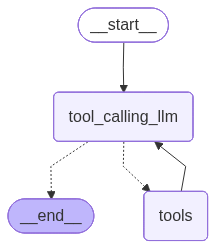

✅ LangGraph agent compiled.


In [78]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import AIMessage, HumanMessage
from IPython.display import Image, display


class GraphState(TypedDict):
    messages: Annotated[list, add_messages]
    user_id: str


def tool_calling_llm(state: GraphState):
    """Agent node: call LLM with tools. Injects user-specific system prompt."""
    user_id = state.get("user_id", "unknown")
    system_msg = SystemMessage(content=build_system_prompt(user_id))
    all_messages = [system_msg] + list(state["messages"])
    response = llm.bind_tools(tools).invoke(all_messages)
    return {"messages": [response]}


# Build graph
builder = StateGraph(GraphState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile()

# Visualise
display(Image(graph.get_graph().draw_mermaid_png()))
print("✅ LangGraph agent compiled.")

## 6. (Optional) Seed test data into MongoDB
Run the sub-cells below once to populate sample watched movies and backdated chat topics.

In [79]:
# ── Seed backdated chat topics for testing ───────────────────────────────────
# Run this once to simulate the scenario described in the notebook intro.
# Adjust SEED_USER and the timedelta values as needed.

from datetime import timedelta

SEED_USER = "bob"  # change to match your user ID

col = get_topics_collection()

# Remove any existing seeded topics for a clean test
col.delete_many({"user_id": SEED_USER, "_seeded": True})

now = datetime.now(timezone.utc)

seed_topics = [
    {
        "user_id": SEED_USER,
        "topic_description": "FIFA/football movies",
        "movies_discussed": ["Goal!", "Victory", "Bend It Like Beckham", "The Two Escobars"],
        "timestamp": now - timedelta(days=7),   # last week Monday
        "_seeded": True,
    },
    {
        "user_id": SEED_USER,
        "topic_description": "Spider-Man franchise",
        "movies_discussed": [
            "Spider-Man: Into the Spider-Verse",
            "Spider-Man: No Way Home",
            "The Amazing Spider-Man",
        ],
        "timestamp": now - timedelta(days=5),   # last week Wednesday
        "_seeded": True,
    },
    {
        "user_id": SEED_USER,
        "topic_description": "Christopher Nolan movies",
        "movies_discussed": [
            "Inception", "Interstellar", "The Dark Knight",
            "Memento", "Tenet", "Dunkirk",
        ],
        "timestamp": now - timedelta(days=1),   # yesterday
        "_seeded": True,
    },
]

col.insert_many(seed_topics)
print(f"✅ Seeded {len(seed_topics)} backdated topics for '{SEED_USER}'.")

# Verify
for t in col.find({"user_id": SEED_USER}).sort("timestamp", 1):
    print(f"  • {t['timestamp'].strftime('%Y-%m-%d')}  {t['topic_description']}")

✅ Seeded 3 backdated topics for 'bob'.
  • 2026-06-14  FIFA/football movies
  • 2026-06-16  Spider-Man franchise
  • 2026-06-20  Christopher Nolan movies
  • 2026-06-21  Batman movies


## 7. Chat!
Enter your user ID when prompted, then ask for recommendations.

In [ ]:
# -- Interactive Movie Recommendation Chat -----------------------------------
from langchain_core.messages import AIMessage, HumanMessage
from groq import BadRequestError

# Ask for user identity once per session
user_id = input("Enter your user ID (e.g. alice, bob): ").strip()
if not user_id:
    user_id = "guest"

print(f"\n🎬 Movie Recommendation Chatbot  |  User: {user_id}")
print("─" * 55)
print("Ask me for movie recommendations or anything about movies.")
print("Type 'quit' to exit.\n")

conversation_messages = []

while True:
    try:
        user_input = input("You: ").strip()
    except (EOFError, KeyboardInterrupt):
        print("\nGoodbye! Enjoy your movies 🍿")
        break

    if user_input.lower() in ("quit", "exit", "q", "bye"):
        print("Goodbye! Enjoy your movies 🍿")
        break

    if not user_input:
        continue

    conversation_messages.append(HumanMessage(content=user_input))

    try:
        result = graph.invoke(
            {"messages": conversation_messages, "user_id": user_id}
        )
    except BadRequestError:
        # Model generated a malformed tool call -- remove failed message and ask user to retry
        conversation_messages.pop()
        print("\n🤖 Assistant: I had a little hiccup processing that. Could you rephrase your question?\n")
        continue

    # Update history with all messages returned (includes tool messages)
    conversation_messages = result["messages"]

    # Print only the final AI text response
    last_ai = next(
        (m for m in reversed(result["messages"])
         if isinstance(m, AIMessage) and m.content),
        None,
    )
    if last_ai:
        print(f"\n🤖 Assistant: {last_ai.content}\n")



🎬 Movie Recommendation Chatbot  |  User: bob
───────────────────────────────────────────────────────
Ask me for movie recommendations or anything about movies.
Type 'quit' to exit.



## 8. Inspect the database
Verify that recommendations were saved to MongoDB.

In [ ]:
# ── Inspect MongoDB: view a user's full profile ──────────────────────────────
from pymongo import MongoClient
from datetime import datetime, timezone

INSPECT_USER = "bob"   # change to your user_id

client    = MongoClient(MONGODB_URI)
db        = client["movies_db"]
user_doc  = db["users"].find_one({"_id": INSPECT_USER})
topics    = list(db["chat_topics"].find({"user_id": INSPECT_USER}).sort("timestamp", -1))

# ── Watched movies ────────────────────────────────────────────────────────────
if user_doc:
    watched = user_doc.get("watched_movies", [])
    print(f"👤 User: {user_doc['_id']}")
    print(f"\n📽  Watched movies ({len(watched)}):")
    for m in watched:
        if isinstance(m, dict):
            print(f"  • {m.get('title','?')} ({m.get('year','?')}) — {', '.join(m.get('genre', []))}")
        else:
            print(f"  • {m}")

    preferred = user_doc.get("preferred_movies", [])
    print(f"\n⭐ Recommended / Preferred movies ({len(preferred)}):")
    for m in preferred:
        title  = m.get("title", "?")
        reason = m.get("reason", "")[:90]
        rec_at = m.get("recommended_at", "")
        print(f"  ★ {title}  [{rec_at}]\n      {reason}...")
else:
    print(f"⚠️  No user found with ID '{INSPECT_USER}' in movies_db.users.")

# ── Chat topics (time-priority history) ───────────────────────────────────────
print(f"\n🗂  Chat topic history ({len(topics)}) — newest first:")
if not topics:
    print("  (none yet)")
else:
    now = datetime.now(timezone.utc)
    for t in topics:
        ts = t["timestamp"]
        if ts.tzinfo is None:
            ts = ts.replace(tzinfo=timezone.utc)
        days  = (now - ts).days
        hours = int((now - ts).total_seconds() // 3600)
        if hours < 24:
            age = f"{hours}h ago"
        elif days == 1:
            age = "yesterday"
        else:
            age = f"{days} days ago"
        movies = ", ".join(t.get("movies_discussed", []))
        print(f"  [{age}]  {t['topic_description']}")
        print(f"           movies: {movies or 'none'}")
        print()

👤 User: bob

📽  Watched movies (0):

⭐ Recommended / Preferred movies (21):
  ★ The Shawshank Redemption  [2026-06-21T19:37:29.185476+00:00]
      Recommended due to interest in Christopher Nolan movies...
  ★ Joker  [2026-06-21T19:37:29.182525+00:00]
      Recommended due to recent interest in Batman movies...
  ★ Captain America: The Winter Soldier  [2026-06-21T19:37:29.188250+00:00]
      Recommended due to past interest in the Spider-Man franchise...
  ★ Green Street Hooligans  [2026-06-21T19:37:29.188250+00:00]
      Recommended due to past interest in FIFA/football movies...
  ★ Inglourious Basterds  [2026-06-21T19:37:29.189250+00:00]
      Recommended due to themes found in recent topics...
  ★ The Joker  [2026-06-21T19:38:47.487604+00:00]
      Recent interest in Batman movies with VERY HIGH PRIORITY...
  ★ Birds of Prey (and the Fantabulous Emancipation of One Harley Quinn)  [2026-06-21T19:38:47.488829+00:00]
      Recent interest in Batman movies with VERY HIGH PRIORITY...
  